### **Linear SVM-based classification with non lexical features**

This notebook implements a classification approach relying exclusively on non lexical features, which capture the syntactic structure, readability, and stylistic complexity of the texts. After dropping all textual columns, the numeric features are normalized using a StandardScaler. A Linear Support Vector Machine (LinearSVC) is evaluated across different regularization parameters (C values) using 5 fold Cross Validation on the training data. The optimal configuration is then retrained on the entire training set and evaluated on the Validation and Test sets. Furthermore, the top 5 documents from the test set where the model shows the highest uncertainty are extracted. Finally, the 20 most relevant features for the classification task are identified, and visual diagnostics (Confusion Matrix, ROC Curve, and Precision Recall Curve) are plotted to comprehensively assess the model's performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from IPython.display import display

### Data loading and feature selection

In [2]:
df_train = pd.read_pickle("../data/enriched/train_final.pkl")
df_val = pd.read_pickle("../data/enriched/val_final.pkl")  
df_test = pd.read_pickle("../data/enriched/test_final.pkl")

# Extract the target vectors
y_train = df_train['label'].copy()
y_val = df_val['label'].copy()
y_test = df_test['label'].copy()

# Identify columns to drop in order to isolate purely numeric non-lexical features
columns_to_drop = [
    'doc_id', 'text', 'tokens', 'lemmas', 'pos', 
    'tokens_processed', 'lemmas_processed', 'pos_processed', 'label'
]

# Create feature matrices by dropping textual and target columns
# errors='ignore' ensures no error is thrown if a column is already missing
X_train = df_train.drop(columns=columns_to_drop, errors='ignore')
X_val = df_val.drop(columns=columns_to_drop, errors='ignore')
X_test = df_test.drop(columns=columns_to_drop, errors='ignore')

print(f"Train features shape: {X_train.shape}")
print(f"Validation features shape: {X_val.shape}")
print(f"Test features shape: {X_test.shape}\n")

Train features shape: (4000, 143)
Validation features shape: (2000, 143)
Test features shape: (2000, 143)



### Model selection via cross-validation

In [3]:
# A dictionary is defined to explore different regularization values (C) for LinearSVC
configs = {
    "LinearSVM_C_0.01": LinearSVC(C=0.01, random_state=42, dual=False, max_iter=2000),
    "LinearSVM_C_0.1": LinearSVC(C=0.1, random_state=42, dual=False, max_iter=2000),
    "LinearSVM_C_1.0": LinearSVC(C=1.0, random_state=42, dual=False, max_iter=2000),
    "LinearSVM_C_10.0": LinearSVC(C=10.0, random_state=42, dual=False, max_iter=2000)
}

best_score = 0
best_model_name = None
best_clf = None

# Iterate over each configuration defined in the 'configs' dictionary
for model_name, classifier in configs.items():
    
    # Build a pipeline with a Scaler (mandatory for non-lexical numeric features)
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", classifier)
    ])

    # Evaluation via 5-fold cross-validation
    scores = cross_val_score(
        pipeline,
        X_train, 
        y_train,
        cv=5,
        scoring="f1_macro",
        n_jobs=-1
    )

    mean_score = np.mean(scores)
    print(f"Configuration: {model_name}")
    print(f"Mean Macro-F1: {mean_score:.4f}\n")
    
    if mean_score > best_score:
        best_score = mean_score
        best_model_name = model_name
        best_clf = classifier

print(f"*** Best Configuration: {best_model_name} (Macro-F1: {best_score:.4f}) ***\n")

Configuration: LinearSVM_C_0.01
Mean Macro-F1: 0.9410

Configuration: LinearSVM_C_0.1
Mean Macro-F1: 0.9455

Configuration: LinearSVM_C_1.0
Mean Macro-F1: 0.9500

Configuration: LinearSVM_C_10.0
Mean Macro-F1: 0.9490

*** Best Configuration: LinearSVM_C_1.0 (Macro-F1: 0.9500) ***



### Final training and evaluation

--- Retraining Best Configuration (LinearSVM_C_1.0) on Full Train Set ---

=== Train Set Evaluation ===
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      2000
           1       0.97      0.96      0.97      2000

    accuracy                           0.97      4000
   macro avg       0.97      0.97      0.97      4000
weighted avg       0.97      0.97      0.97      4000

=== Validation Set Evaluation ===
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1000
           1       0.96      0.96      0.96      1000

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000

=== Test Set Evaluation ===
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      1000
           1       0.93      0.83      0.87      1000

    accuracy    

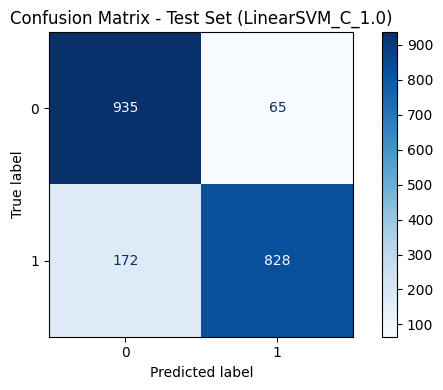

In [4]:
print(f"--- Retraining Best Configuration ({best_model_name}) on Full Train Set ---")

# Initialize the optimal pipeline with the winning classifier
best_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", best_clf)
])

# Train on the full training set
best_pipeline.fit(X_train, y_train)

# Predictions on the three splits
pred_train = best_pipeline.predict(X_train)
pred_val = best_pipeline.predict(X_val)
pred_test = best_pipeline.predict(X_test)

# Print the classification reports
print("\n=== Train Set Evaluation ===")
print(classification_report(y_train, pred_train, zero_division=0))

print("=== Validation Set Evaluation ===")
print(classification_report(y_val, pred_val, zero_division=0))

print("=== Test Set Evaluation ===")
print(classification_report(y_test, pred_test, zero_division=0))

# Confusion Matrix visualization
cm = confusion_matrix(y_test, pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_pipeline.classes_)

fig_cm, ax_cm = plt.subplots(figsize=(6, 4))
disp.plot(ax=ax_cm, cmap="Blues", xticks_rotation=0)
plt.title(f"Confusion Matrix - Test Set ({best_model_name})")
plt.tight_layout()
plt.show()

### ROC and PR curve

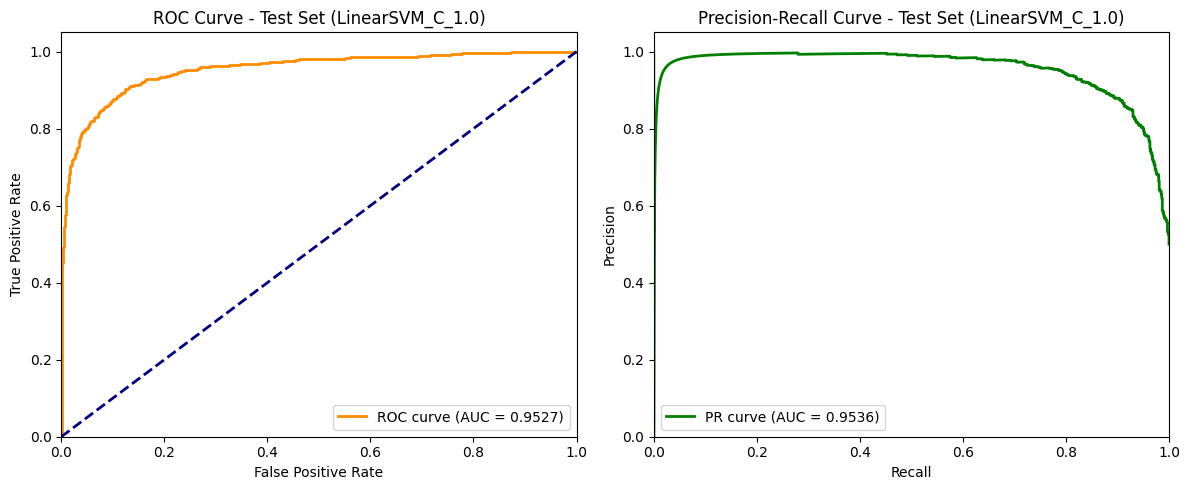

In [5]:
#Extract decision_function scores for LinearSVC (required for curves)
y_scores = best_pipeline.decision_function(X_test)

# Create a figure with two side-by-side subplots
fig_curves, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') 
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title(f'ROC Curve - Test Set ({best_model_name})')
ax1.legend(loc="lower right")

# PR Curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_scores)
pr_auc = average_precision_score(y_test, y_scores)

ax2.plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title(f'Precision-Recall Curve - Test Set ({best_model_name})')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

### Most uncertain documents (test set)

In [6]:
print("\n--- Top 5 Most Uncertain Documents in Test Set ---")

# Uncertainty is defined as the absolute distance to the decision boundary.
# Values closest to 0 indicate maximum uncertainty.
distances = np.abs(best_pipeline.decision_function(X_test))

# Get the indices of the 5 documents with the smallest distance
uncertain_indices = np.argsort(distances)[:5]

# Collect the data in a list of dictionaries
uncertain_data = []
for i, idx in enumerate(uncertain_indices):
    uncertain_data.append({
        "Rank": i + 1,
        "Original_Index": idx,
        "Distance": round(distances[idx], 6),
        "True_Label": df_test['label'].iloc[idx],
        "Predicted_Label": pred_test[idx],
        "Text_Snippet": df_test['text'].iloc[idx][:150] + "..."
    })

# Convert to a Pandas DataFrame for enhanced visualization
df_uncertain = pd.DataFrame(uncertain_data)

# Display the DataFrame (renders as a formatted HTML table in Jupyter Notebooks)
display(df_uncertain)


--- Top 5 Most Uncertain Documents in Test Set ---


,Rank,Original_Index,Distance,True_Label,Predicted_Label,Text_Snippet
0,1,1480,0.000214,0,1,Secondo il quotidiano Standard le violenze pro...
1,2,409,0.002330,1,0,Uno studio recente della Harvard School of Pub...
2,3,1114,0.006488,1,1,"Un vero e proprio serpentone di persone, con a..."
3,4,1594,0.008000,1,0,"Lanciato immediatamente l'allarme, sul posto s..."
4,5,896,0.008919,0,0,"Servirà il 3-0 o il 4-1. Tutto in salita, quin..."


### Top 20 most relevant features

--- Top 20 Most Relevant Features ---
                  Feature  Importance
                 n_tokens    3.084379
   n_prepositional_chains    2.045764
          upos_dist_PUNCT    1.858292
             dep_dist_det    1.684660
            upos_dist_DET    1.596626
      ttr_form_chunks_200    1.385363
           dep_dist_punct    1.333805
          dep_dist_advmod    1.147981
           upos_dist_PRON    1.140248
          lexical_density    1.112308
            upos_dist_NUM    0.938149
            upos_dist_ADV    0.799547
avg_subordinate_chain_len    0.758612
    dep_dist_flat:foreign    0.743100
            dep_dist_amod    0.730732
          upos_dist_PROPN    0.725661
       dep_dist_acl:relcl    0.714151
           upos_dist_VERB    0.695653
          tokens_per_sent    0.653780
     ttr_lemma_chunks_200    0.620043


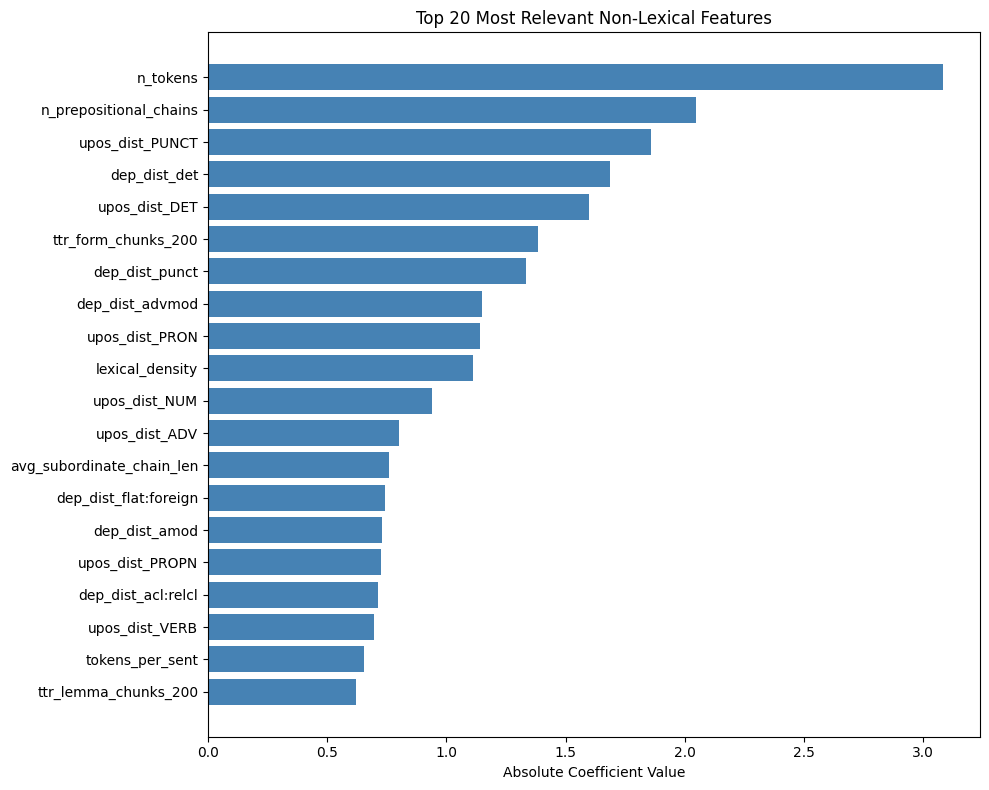

In [7]:
print("--- Top 20 Most Relevant Features ---")
# Extract the trained LinearSVC model from the pipeline
trained_svc = best_pipeline.named_steps["clf"]

# Extract feature names from the DataFrame
feature_names = X_train.columns

# The relevance of a feature in a linear SVM is given by the absolute value of its coefficient
feature_importances = np.abs(trained_svc.coef_[0])

# Create a DataFrame to store and sort the features
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

top_20_features = importance_df.head(20)

# Print the top 20 features
print(top_20_features.to_string(index=False))

# Plot the top 20 features for better visualization
plt.figure(figsize=(10, 8))
# Slicing with [::-1] to plot the most important at the top of the horizontal bar chart
plt.barh(top_20_features['Feature'][::-1], top_20_features['Importance'][::-1], color='steelblue')
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 20 Most Relevant Non-Lexical Features')
plt.tight_layout()
plt.show()